In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grouplens/movielens-20m-dataset")

print("Path to dataset files:", path)

/home/sahildev/development/DS_Practice/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/sahildev/.cache/kagglehub/datasets/grouplens/movielens-20m-dataset/versions/1


In [3]:
df_tag = pd.read_csv(os.path.join(path, 'tag.csv'))
df_rating = pd.read_csv(os.path.join(path, 'rating.csv'))
df_link = pd.read_csv(os.path.join(path, 'link.csv'))
df_movie = pd.read_csv(os.path.join(path, 'movie.csv'))
df_genome_scores = pd.read_csv(os.path.join(path, 'genome_scores.csv'))
df_genome_tags = pd.read_csv(os.path.join(path, 'genome_tags.csv'))

### What data and relation are :
- **tag** : user mapped tags to a movie
- **movie** : core movie with genre it is
- **rating** : user provided rating to a movie
- **link** : relation for a movie to imdb and tmdb id
- **genome_tag** : genome tag identifier
- **genome_score** : tag relevence to a particular movie

In [4]:
df_movie.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


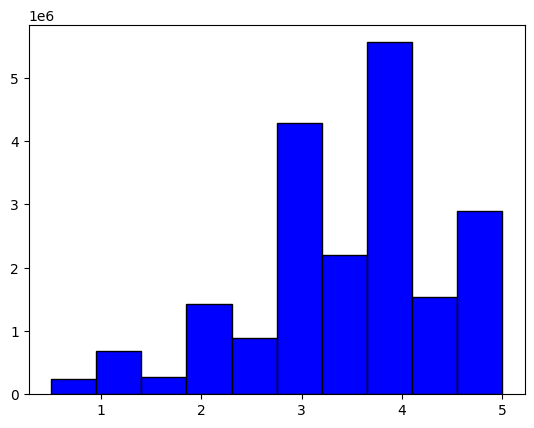

In [5]:
user_activity = df_rating.groupby("rating").agg({"userId": "count"}).reset_index()
plt.hist(df_rating["rating"] , bins=10 , color="blue" , edgecolor="black")
plt.show()

In [6]:
# Segmenting genres into one-hot encoded features

df_movie['tags'] = df_movie['genres'].str.split("|")
mlb = MultiLabelBinarizer()
one_hot = mlb.fit_transform(df_movie['tags'])
one_hot_df = pd.DataFrame(one_hot, columns=[f"genre_{genre}" for genre in mlb.classes_])
df_movie = pd.concat([df_movie.drop('tags', axis=1), one_hot_df], axis=1)
df_movie.head()


,movieId,title,genres,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print(df_movie["genre_Action"].sum())

3520


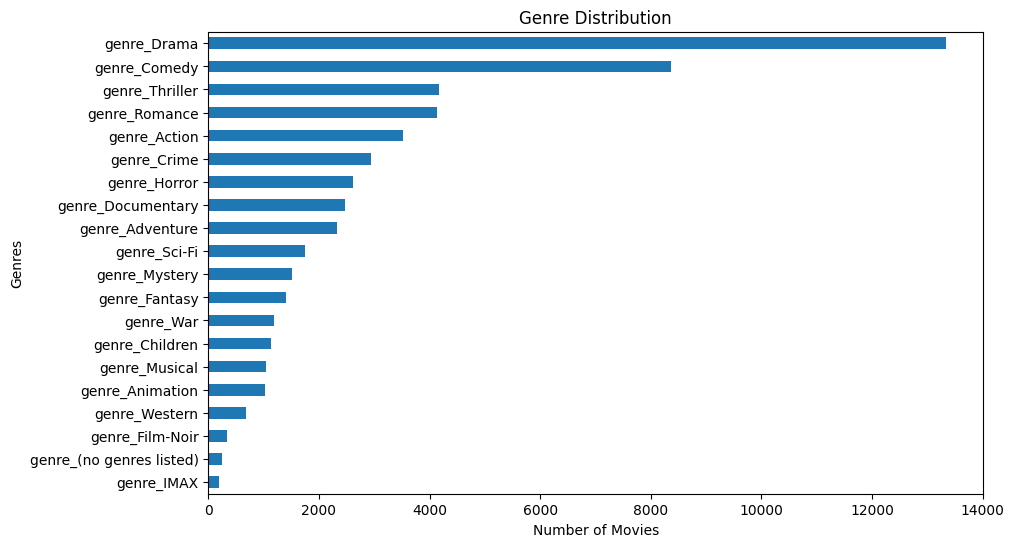

In [8]:
# Analyzing Genre Distribution

# Select only genre columns
genre_df = df_movie.loc[:, df_movie.columns.str.startswith("genre_")]

# Compute total counts per genre
genre_counts = genre_df.sum().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
genre_counts.plot(kind="barh")
plt.xlabel("Number of Movies")
plt.ylabel("Genres")
plt.title("Genre Distribution")
plt.show()

In [9]:
df_movie.head()

,movieId,title,genres,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_rating.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


: 

In [ ]:
df_movie_rating = pd.merge(
    df_rating,
    df_movie,
    on="movieId",
    how="left"
)

df_movie_rating.head()